# 🐼 Pandas vs 🐻‍❄️ Polars — Speed Test on 2 Million Rows

### What I am testing:
- Same dataset, same 4 tasks
- Pandas way vs Polars way
- Which one is faster? (spoiler: the answer surprised me!)


## Step 1 — Install the libraries

First, let's make sure both libraries are installed.  
Pandas you probably already have. Polars needs to be installed.

In [1]:

import pandas as pd
import polars as pl

print("Pandas version :", pd.__version__)
print("Polars version :", pl.__version__)
print("Both libraries loaded successfully!")


Pandas version : 2.2.2
Polars version : 1.35.2
Both libraries loaded successfully!


## Step 2 — Creating a Fake E-Commerce Dataset

I am creating a fake dataset that looks like real e-commerce orders.  
It has **2 million rows** big enough to see a real speed difference.

| Column | What it means |
|---|---|
| order_id | unique ID for each order |
| user_id | who placed the order |
| product_id | which product was ordered |
| category | product category (Electronics, Books, etc.) |
| quantity | how many items ordered |
| price | price per item in ₹ |
| order_date | when the order was placed |


In [28]:
import numpy as np

# Set a random seed so we get same data every time
np.random.seed(42)

# How many rows do we want?
n = 2_000_000  # 2 million rows

# Create some sample values to pick from
users    = [f"user_{i}"    for i in range(10000)]
products = [f"product_{i}" for i in range(500)]
categories = ["Electronics", "Clothing", "Food", "Books", "Sports", "Beauty", "Home"]

# Build the dataset as a dictionary
data = {
    "order_id"   : np.arange(n),
    "user_id"    : np.random.choice(users, n),
    "product_id" : np.random.choice(products, n),
    "category"   : np.random.choice(categories, n),
    "quantity"   : np.random.randint(1, 10, n),
    "price"      : np.round(np.random.uniform(10, 5000, n), 2),
    "order_date" : pd.date_range("2022-01-01", periods=n, freq="30s"),
}

# Create Pandas DataFrame
df_pandas = pd.DataFrame(data)

# Create Polars DataFrame from the same data
df_polars = pl.from_pandas(df_pandas)

print(f"Dataset created!")
print(f"Total rows  : {n:,}")
print(f"Total columns: {len(df_pandas.columns)}")
print()
df_pandas.head(3)


Dataset created!
Total rows  : 2,000,000
Total columns: 7



,order_id,user_id,product_id,category,quantity,price,order_date
0,0,user_7270,product_336,Beauty,2,777.42,2022-01-01 00:00:00
1,1,user_860,product_334,Sports,1,708.13,2022-01-01 00:00:30
2,2,user_5390,product_452,Beauty,5,893.39,2022-01-01 00:01:00


## Step 3 — Memory Usage Comparison

Before we even run any tasks, let's see how much RAM each library uses for the same data.


In [3]:
pandas_memory = df_pandas.memory_usage(deep=True).sum() / 1024**2
polars_memory = df_polars.estimated_size() / 1024**2

print(f"Pandas memory usage : {pandas_memory:.1f} MB")
print(f"Polars memory usage : {polars_memory:.1f} MB")
print()
print(f"Polars uses {pandas_memory - polars_memory:.1f} MB LESS memory for the same data!")
print(f"That is a {(1 - polars_memory/pandas_memory)*100:.0f}% saving in RAM.")


Pandas memory usage : 390.9 MB
Polars memory usage : 110.5 MB

Polars uses 280.4 MB LESS memory for the same data!
That is a 72% saving in RAM.


## Task 1 — Total Revenue per Category

**The question:** How much total revenue did each category make?

This is a simple `groupby` + `sum` something we do all the time in data analysis.


In [12]:
import time
#Using Pandas
start = time.perf_counter()

result_pandas_t1 = (
    df_pandas
    .groupby("category")["price"]   # group by category, pick price column
    .sum()                           # sum up all prices
    .reset_index()                   # make it a clean table again
    .rename(columns={"price": "total_revenue"})
)

pandas_time_t1 = time.perf_counter() - start


In [10]:
#Polars
start = time.perf_counter()

result_polars_t1 = (
    df_polars
    .lazy()                          # polars: build the plan first, don't run yet
    .group_by("category")            # group by category
    .agg(
        pl.col("price").sum().alias("total_revenue")   # sum up prices
    )
    .collect()                       # NOW run everything
)

polars_time_t1 = time.perf_counter() - start


In [11]:
#Results
print(f"Task 1: Revenue per Category")
print(f"  Pandas  took : {pandas_time_t1:.3f} seconds")
print(f"  Polars  took : {polars_time_t1:.3f} seconds")
print(f"  Winner  : {'Polars' if polars_time_t1 < pandas_time_t1 else 'Pandas'} "
      f"({max(pandas_time_t1, polars_time_t1)/min(pandas_time_t1, polars_time_t1):.1f}x faster)")
print()
print("Pandas result:")
print(result_pandas_t1.sort_values("total_revenue", ascending=False))

Task 1: Revenue per Category
  Pandas  took : 0.459 seconds
  Polars  took : 0.133 seconds
  Winner  : Polars (3.4x faster)

Pandas result:
      category  total_revenue
1        Books   7.176623e+08
0       Beauty   7.163277e+08
6       Sports   7.161843e+08
4         Food   7.159606e+08
5         Home   7.155766e+08
3  Electronics   7.151655e+08
2     Clothing   7.141403e+08


## Task 2 — Top 10 Users by Total Spend

**The question:** Which 10 users spent the most money overall?

Here we need to calculate `price × quantity` first, then group, then sort.  
This involves more steps — let's see who handles it better.


In [15]:
#Using Pandas
start = time.perf_counter()

result_pandas_t2 = (
    df_pandas
    .assign(revenue = df_pandas["price"] * df_pandas["quantity"])  # new column = price x qty
    .groupby("user_id")["revenue"]
    .sum()
    .nlargest(10)
    .reset_index()
)

pandas_time_t2 = time.perf_counter() - start

In [16]:
#Using Polars
start = time.perf_counter()

result_polars_t2 = (
    df_polars
    .lazy()
    .with_columns(
        (pl.col("price") * pl.col("quantity")).alias("revenue")   # new column = price x qty
    )
    .group_by("user_id")
    .agg(pl.col("revenue").sum())
    .sort("revenue", descending=True)
    .limit(10)
    .collect()
)

polars_time_t2 = time.perf_counter() - start

In [17]:
#Results
print(f"Task 2: Top 10 Users by Spend")
print(f"  Pandas  took : {pandas_time_t2:.3f} seconds")
print(f"  Polars  took : {polars_time_t2:.3f} seconds")
print(f"  Winner  : {'Polars' if polars_time_t2 < pandas_time_t2 else 'Pandas'} "
      f"({max(pandas_time_t2, polars_time_t2)/min(pandas_time_t2, polars_time_t2):.1f}x faster)")
print()
print("Pandas result (top 10 spenders):")
print(result_pandas_t2)

Task 2: Top 10 Users by Spend
  Pandas  took : 0.418 seconds
  Polars  took : 0.145 seconds
  Winner  : Polars (2.9x faster)

Pandas result (top 10 spenders):
     user_id     revenue
0  user_4145  3501693.10
1  user_2486  3417240.97
2  user_4507  3413597.84
3  user_7760  3379459.37
4  user_3771  3350612.95
5  user_9233  3291529.12
6  user_1823  3288764.17
7  user_5414  3273228.80
8  user_5628  3265696.76
9  user_8107  3258541.37


## Task 3 — Filter + Group (Electronics orders above ₹1000)

**The question:** Among Electronics products priced above ₹1000, which products were ordered the most?

This tests filtering first, then grouping — a very common real-world pattern.


In [21]:
#Using Pandas
start = time.perf_counter()

# Step 1: filter rows we want
electronics_df = df_pandas[
    (df_pandas["category"] == "Electronics") &   # only Electronics
    (df_pandas["price"] > 1000)                   # only price above 1000
]

# Step 2: group by product and sum quantities
result_pandas_t3 = (
    electronics_df
    .groupby("product_id")["quantity"]
    .sum()
    .reset_index()
    .sort_values("quantity", ascending=False)
    .head(10)
)

pandas_time_t3 = time.perf_counter() - start


In [22]:
#Using Polars
start = time.perf_counter()

result_polars_t3 = (
    df_polars
    .lazy()
    .filter(
        (pl.col("category") == "Electronics") &   # only Electronics
        (pl.col("price") > 1000)                   # only price above 1000
    )
    .group_by("product_id")
    .agg(pl.col("quantity").sum())
    .sort("quantity", descending=True)
    .limit(10)
    .collect()
)

polars_time_t3 = time.perf_counter() - start

In [23]:
#Results
print(f"Task 3: Filter + Group (Electronics > Rs.1000)")
print(f"  Pandas  took : {pandas_time_t3:.3f} seconds")
print(f"  Polars  took : {polars_time_t3:.3f} seconds")
print(f"  Winner  : {'Polars' if polars_time_t3 < pandas_time_t3 else 'Pandas'} "
      f"({max(pandas_time_t3, polars_time_t3)/min(pandas_time_t3, polars_time_t3):.1f}x faster)")
print()
print("Top 10 Electronics products by quantity ordered:")
print(result_pandas_t3)

Task 3: Filter + Group (Electronics > Rs.1000)
  Pandas  took : 0.288 seconds
  Polars  took : 0.030 seconds
  Winner  : Polars (9.7x faster)

Top 10 Electronics products by quantity ordered:
      product_id  quantity
478    product_8      2684
303  product_371      2642
114  product_200      2636
310  product_378      2603
306  product_374      2570
383  product_443      2570
127  product_212      2561
192  product_271      2557
87   product_177      2543
347  product_410      2530


## Task 4 — Monthly Revenue Trend

**The question:** What was the total revenue for each month of 2022?

This requires extracting the month from a date column, then grouping.  
Date operations can be slow — let's see the difference here.


In [24]:
#Using Pandas Way
start = time.perf_counter()

# Make a copy so we don't change the original
df_pandas_copy = df_pandas.copy()

# Extract month from the date
df_pandas_copy["month"] = df_pandas_copy["order_date"].dt.to_period("M")

# Group by month and sum revenue
result_pandas_t4 = (
    df_pandas_copy
    .groupby("month")["price"]
    .sum()
    .reset_index()
    .rename(columns={"price": "total_revenue"})
)

pandas_time_t4 = time.perf_counter() - start

In [25]:
#Using Polar Way
start = time.perf_counter()

result_polars_t4 = (
    df_polars
    .lazy()
    .with_columns(
        pl.col("order_date").dt.truncate("1mo").alias("month")   # round date down to month
    )
    .group_by("month")
    .agg(pl.col("price").sum().alias("total_revenue"))
    .sort("month")
    .collect()
)

polars_time_t4 = time.perf_counter() - start

In [26]:
# ── Results ─────────────────────────────────────────────────────────────────
print(f"Task 4: Monthly Revenue Trend")
print(f"  Pandas  took : {pandas_time_t4:.3f} seconds")
print(f"  Polars  took : {polars_time_t4:.3f} seconds")
print(f"  Winner  : {'Polars' if polars_time_t4 < pandas_time_t4 else 'Pandas'} "
      f"({max(pandas_time_t4, polars_time_t4)/min(pandas_time_t4, polars_time_t4):.1f}x faster)")
print()
print("Monthly revenue (first 6 months):")
print(result_pandas_t4.head(6))

Task 4: Monthly Revenue Trend
  Pandas  took : 0.274 seconds
  Polars  took : 0.195 seconds
  Winner  : Polars (1.4x faster)

Monthly revenue (first 6 months):
     month  total_revenue
0  2022-01   2.238488e+08
1  2022-02   2.023679e+08
2  2022-03   2.231933e+08
3  2022-04   2.158496e+08
4  2022-05   2.235794e+08
5  2022-06   2.157265e+08


# **Overall Summary :**

In [29]:
print("Memory usage:")
print(f"  Pandas : {pandas_memory:.1f} MB")
print(f"  Polars : {polars_memory:.1f} MB")
print(f"  Polars saves {pandas_memory - polars_memory:.1f} MB ({(1 - polars_memory/pandas_memory)*100:.0f}% less RAM)")


Memory usage:
  Pandas : 390.9 MB
  Polars : 110.5 MB
  Polars saves 280.4 MB (72% less RAM)


## Bonus — Let's Visualize the Results!

A bar chart makes it easy to see where each library wins.


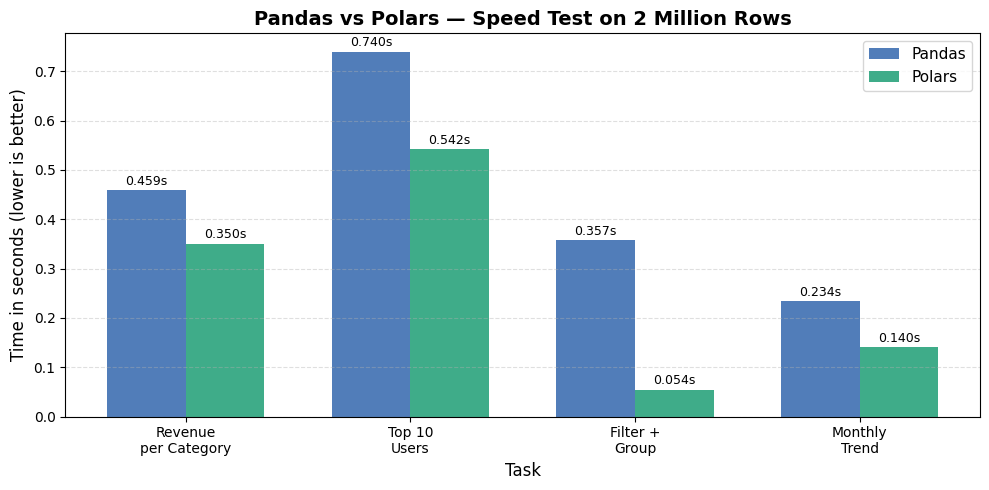

In [30]:
import matplotlib.pyplot as plt
import numpy as np

tasks_short = ["Revenue\nper Category", "Top 10\nUsers", "Filter +\nGroup", "Monthly\nTrend"]

x = np.arange(len(tasks_short))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars_pandas = ax.bar(x - bar_width/2, pandas_times, bar_width,
                     label="Pandas", color="#3266ad", alpha=0.85)
bars_polars = ax.bar(x + bar_width/2, polars_times, bar_width,
                     label="Polars", color="#1D9E75", alpha=0.85)

# Add value labels on top of each bar
for bar in bars_pandas:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}s", ha="center", va="bottom", fontsize=9)

for bar in bars_polars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}s", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Task", fontsize=12)
ax.set_ylabel("Time in seconds (lower is better)", fontsize=12)
ax.set_title("Pandas vs Polars — Speed Test on 2 Million Rows", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(tasks_short)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("pandas_vs_polars_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()
